# Agricultural Data Preprocessing and Visualization Using Python

### To improve the quality and structure of agricultural crop production data for better visualization, understanding, and future machine learning applications.

# The agricultural dataset was acquired from Kaggle, a publicly available platform for data science and machine learning datasets.

## Dataset Link:
## https://www.kaggle.com/datasets/pyatakov/india-agriculture-crop-production

## Objectives 

1. To collect and preprocess agricultural crop production data using Python.

2. To handle missing values, inconsistencies, and duplicate records in the dataset.

3. To detect and treat outliers using clipping and logarithmic transformation techniques.

4. To improve the quality and interpretability of the dataset through preprocessing and transformation methods.

5. To perform Exploratory Data Visualization using univariate, bivariate, and multivariate analysis techniques.

6. To understand the distributions and relationships among variables such as Area, Production, Yield, Crop, Season, and State.

7. To encode categorical variables and scale numerical variables for further machine learning applications.

8. To prepare a clean and structured agricultural dataset suitable for future data analysis and predictive modeling tasks.

#  Data preparation

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load and view Dataset

In [2]:
df = pd.read_csv(r"C:\Users\cheth\Downloads\archive (18)\India Agriculture Crop Production.csv")
df.head(10)

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296
5,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2003-04,Whole Year,3118.0,Hectare,5182.0,Tonnes,1.661963
6,Andaman and Nicobar Islands,NICOBARS,Banana,2002-03,Whole Year,213.0,Hectare,1278.0,Tonnes,6.000000
7,Andaman and Nicobar Islands,NICOBARS,Banana,2003-04,Whole Year,266.0,Hectare,1763.0,Tonnes,6.627820
8,Andaman and Nicobar Islands,SOUTH ANDAMANS,Banana,2002-03,Whole Year,1524.0,Hectare,10882.0,Tonnes,7.140420
9,Andaman and Nicobar Islands,SOUTH ANDAMANS,Banana,2003-04,Whole Year,1530.0,Hectare,11558.0,Tonnes,7.554248


## Check Dataset Shape

In [3]:
df.shape

(345407, 10)

## Check Column Names

In [4]:
df.columns

Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units',
       'Production', 'Production Units', 'Yield'],
      dtype='object')

## Check Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345407 entries, 0 to 345406
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             345407 non-null  object 
 1   District          345407 non-null  object 
 2   Crop              345375 non-null  object 
 3   Year              345407 non-null  object 
 4   Season            345406 non-null  object 
 5   Area              345374 non-null  float64
 6   Area Units        345407 non-null  object 
 7   Production        340414 non-null  float64
 8   Production Units  345407 non-null  object 
 9   Yield             345374 non-null  float64
dtypes: float64(3), object(7)
memory usage: 26.4+ MB


## Statistical Summary

In [6]:
df.describe()

,Area,Production,Yield
count,3.453740e+05,3.404140e+05,345374.000000
mean,1.167019e+04,9.583711e+05,79.407569
std,4.583843e+04,2.152986e+07,916.628744
min,4.000000e-03,0.000000e+00,0.000000
25%,7.400000e+01,8.700000e+01,0.546742
50%,5.320000e+02,7.170000e+02,1.000000
75%,4.110000e+03,7.176000e+03,2.467080
max,8.580100e+06,1.597800e+09,43958.333333


# Interpretation

## The statistical summary before preprocessing indicates that the numerical variables Area, Production, and Yield contain significant variability and extreme values. The large differences between the minimum, maximum, mean, and standard deviation values suggest the presence of substantial outliers and high positive skewness in the dataset.

## The Area and Production variables exhibit extremely large maximum values compared to their median values, indicating that a small number of observations contain exceptionally high agricultural area and production values. Similarly, the Yield variable shows a very high maximum value relative to its quartiles, confirming the presence of extreme outliers.

## These observations highlight the need for preprocessing techniques such as outlier treatment, clipping, and logarithmic transformation to reduce skewness, improve data distribution, and enhance the interpretability of the dataset for further visualization and machine learning applications.

## Check Missing Values

In [7]:
df.isnull().sum()

State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64

## there are some missing values in crop,season, production and yield columns 

## df.duplicated().sum()

In [8]:
df.duplicated().sum()

0

## Check Unique Values

In [9]:
categorical_cols = [
    'State',
    'District',
    'Crop',
    'Year',
    'Season',
    'Area Units',
    'Production Units'
]

for col in categorical_cols:
    print("\n====================")
    print("Column :", col)
    print("====================")
    print(df[col].unique())


Column : State
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra and Nagar Haveli'
 'Daman and Diu' 'Delhi' 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh'
 'Jammu and Kashmir' 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh'
 'Maharashtra' 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha'
 'Puducherry' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Telangana' 'Laddakh']

Column : District
['NICOBARS' 'NORTH AND MIDDLE ANDAMAN' 'SOUTH ANDAMANS' 'ANANTAPUR'
 'EAST GODAVARI' 'KRISHNA' 'VIZIANAGARAM' 'WEST GODAVARI' 'ADILABAD'
 'CHITTOOR' 'GUNTUR' 'KADAPA' 'KARIMNAGAR' 'KHAMMAM' 'KURNOOL'
 'MAHBUBNAGAR' 'MEDAK' 'NALGONDA' 'NIZAMABAD' 'PRAKASAM' 'RANGAREDDI'
 'SPSR NELLORE' 'SRIKAKULAM' 'VISAKHAPATANAM' 'WARANGAL' 'CHANGLANG'
 'DIBANG VALLEY' 'EAST KAMENG' 'EAST SIANG' 'KURUNG KUMEY' 'LOHIT'
 'LOWER DIBANG VALLEY' 'LOWER SUBANSIRI' 'PAPUM PARE' 'TAWANG' 'TIRAP'
 'UPPER

## Remove Extra Spaces

In [10]:
text_cols = [
    'State',
    'District',
    'Crop',
    'Season',
    'Area Units',
    'Production Units'
]

for col in text_cols:
    df[col] = df[col].str.strip()

## Standardize texts i,e Convert Text to Uppercase or title case 

In [11]:
df['State'] = df['State'].str.title()
for col in ['District', 'Crop', 'Season']:
    df[col] = df[col].str.upper()

## Fix State Name Inconsistency

In [12]:
df['State'] = df['State'].replace({
    'Laddakh':'Ladakh'
})

## Fix District Name Inconsistencies

In [13]:
district_mapping = {

    # Karnataka renamed districts
    'BELLARY':'BALLARI',
    'BAGALKOT':'BAGALKOTE',
    'BELGAUM':'BELAGAVI',
    'BIJAPUR':'VIJAYAPURA',
    'GULBARGA':'KALABURAGI',
    'MYSORE':'MYSURU',
    'SHIMOGA':'SHIVAMOGGA',
    'TUMKUR':'TUMAKURU',
    'UTTAR KANNAD':'UTTARA KANNADA',
    'DAKSHIN KANNAD':'DAKSHINA KANNADA',
    'CHIKMAGALUR':'CHIKKAMAGALURU',
    'CHAMARAJANAGAR':'CHAMARAJANAGARA',

    # Tamil Nadu renamed district
    'TUTICORIN':'THOOTHUKUDI',

    # Remove invalid district naming
    'DELHI_TOTAL':'DELHI',

    # Union territory inconsistency
    'THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU':
    'DADRA AND NAGAR HAVELI AND DAMAN AND DIU'
}

df['District'] = df['District'].replace(district_mapping)

## Remove Invalid District Entry

In [14]:
df = df[df['District'] != 'S']

## check unique district and state names after handling inconsistencies of those 2 columns 

In [15]:
df['District'].unique()

array(['NICOBARS', 'NORTH AND MIDDLE ANDAMAN', 'SOUTH ANDAMANS',
       'ANANTAPUR', 'EAST GODAVARI', 'KRISHNA', 'VIZIANAGARAM',
       'WEST GODAVARI', 'ADILABAD', 'CHITTOOR', 'GUNTUR', 'KADAPA',
       'KARIMNAGAR', 'KHAMMAM', 'KURNOOL', 'MAHBUBNAGAR', 'MEDAK',
       'NALGONDA', 'NIZAMABAD', 'PRAKASAM', 'RANGAREDDI', 'SPSR NELLORE',
       'SRIKAKULAM', 'VISAKHAPATANAM', 'WARANGAL', 'CHANGLANG',
       'DIBANG VALLEY', 'EAST KAMENG', 'EAST SIANG', 'KURUNG KUMEY',
       'LOHIT', 'LOWER DIBANG VALLEY', 'LOWER SUBANSIRI', 'PAPUM PARE',
       'TAWANG', 'TIRAP', 'UPPER SIANG', 'UPPER SUBANSIRI', 'WEST KAMENG',
       'WEST SIANG', 'BARPETA', 'BONGAIGAON', 'CACHAR', 'DARRANG',
       'DHEMAJI', 'DHUBRI', 'DIBRUGARH', 'DIMA HASAO', 'GOALPARA',
       'GOLAGHAT', 'HAILAKANDI', 'JORHAT', 'KAMRUP', 'KARBI ANGLONG',
       'KARIMGANJ', 'KOKRAJHAR', 'LAKHIMPUR', 'MARIGAON', 'NAGAON',
       'NALBARI', 'SIVASAGAR', 'SONITPUR', 'TINSUKIA', 'ARARIA', 'ARWAL',
       'AURANGABAD', 'BANKA', 'BEGUS

In [16]:
df['State'].unique()

array(['Andaman And Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra And Nagar Haveli', 'Daman And Diu', 'Delhi',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan',
       'Sikkim', 'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
       'West Bengal', 'Telangana', 'Ladakh'], dtype=object)

## deleting row in which district contains state name 

In [17]:
df[df['District'] == 'ANDAMAN AND NICOBAR ISLANDS']

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
85043,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,ARECANUT,2007-08,KHARIF,2439.60,Hectare,3415.44,Tonnes,1.400000
85044,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,ARECANUT,2007-08,RABI,1626.40,Hectare,2276.96,Tonnes,1.400000
85045,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,ARECANUT,2008-09,AUTUMN,4147.00,Hectare,3060.00,Tonnes,0.737883
85046,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,ARECANUT,2008-09,SUMMER,4147.00,Hectare,2660.00,Tonnes,0.641428
85047,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,ARECANUT,2009-10,AUTUMN,4153.00,Hectare,3120.00,Tonnes,0.751264
...,...,...,...,...,...,...,...,...,...,...
85110,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,TURMERIC,2008-09,SUMMER,82.00,Hectare,381.00,Tonnes,4.646341
85111,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,TURMERIC,2009-10,SUMMER,84.00,Hectare,384.00,Tonnes,4.571429
85112,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,URAD,2007-08,RABI,1328.41,Hectare,790.93,Tonnes,0.595396
85113,Andaman And Nicobar Islands,ANDAMAN AND NICOBAR ISLANDS,URAD,2008-09,SUMMER,1174.00,Hectare,638.00,Tonnes,0.543441


In [18]:

df = df[df['District'] != 'ANDAMAN AND NICOBAR ISLANDS']

In [19]:
df[df['District'] == 'ANDAMAN AND NICOBAR ISLANDS']

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield


##  drop area unit column

In [20]:
df.drop('Area Units', axis=1, inplace=True)

## The Area Units column was removed because it contained only a single repeated value (“Hectare”) across all records and therefore provided no analytical significance.

# handle missing values 

In [21]:
df.isnull().sum()

State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Production          4990
Production Units       0
Yield                 33
dtype: int64

## check for skewness for numerical columns 

In [22]:
def skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        return "Approx Normal"
    elif (-1<= skew_value < -0.5) or (0.5<skew_value<=1):
        return"MOderate skew "
    else: 
        return "Highly skewwed"

In [23]:
numeric_cols=df.select_dtypes(include=["number"]).columns
results=[]
for col in numeric_cols:
    skew_val=df[col].skew()
    category=skewness(skew_val)
    results.append({"Column Name":col,"Skew Value":round(skew_val,3),"Skewness":category})
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,Area,41.841,Highly skewwed
1,Production,35.871,Highly skewwed
2,Yield,14.762,Highly skewwed


## impute missing columns in these using median as these columns are highly skewed

In [24]:
num_cols = ['Area', 'Production', 'Yield']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

## drop missing value present in season as there is only one in around 3 lakh rows

In [25]:
df = df.dropna(subset=['Season'])

## impute missing values present in crops using mode as it is categorical and also an important variable in the dataset

In [26]:
df['Crop'] = df['Crop'].fillna(df['Crop'].mode()[0])

In [27]:
df.isnull().sum()

State               0
District            0
Crop                0
Year                0
Season              0
Area                0
Production          0
Production Units    0
Yield               0
dtype: int64

## convert datatype object to category as they are categories of repeated values

In [28]:
category_cols = [
    'State',
    'District',
    'Crop',
    'Year',
    'Season',
    'Production Units'
]

for col in category_cols:
    df[col] = df[col].astype('category')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345204 entries, 0 to 345406
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   State             345204 non-null  category
 1   District          345204 non-null  category
 2   Crop              345204 non-null  category
 3   Year              345204 non-null  category
 4   Season            345204 non-null  category
 5   Area              345204 non-null  float64 
 6   Production        345204 non-null  float64 
 7   Production Units  345204 non-null  category
 8   Yield             345204 non-null  float64 
dtypes: category(6), float64(3)
memory usage: 12.9 MB


# OUTLIER HANDLING

In [30]:
def skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        return "Approx Normal"
    elif (-1<= skew_value < -0.5) or (0.5<skew_value<=1):
        return"MOderate skew "
    else: 
        return "Highly skewwed"
numeric_cols=df.select_dtypes(include=["number"]).columns
results=[]
for col in numeric_cols:
    skew_val=df[col].skew()
    category=skewness(skew_val)
    results.append({"Column Name":col,"Skew Value":round(skew_val,3),"Skewness":category})
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,Area,41.843,Highly skewwed
1,Production,36.133,Highly skewwed
2,Yield,14.763,Highly skewwed


# Interpretation

## The numerical variables Area, Production, and Yield are highly positively skewed. This indicates the presence of extreme values and non-normal distributions in the dataset. Therefore, outlier treatment and transformation techniques are required before further analysis.

In [31]:
#area column
# method :iqr interquartile range
q1=df["Area"].quantile(0.25)
q3=df["Area"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Area"]<lower)|(df["Area"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield
20,Andaman And Nicobar Islands,NICOBARS,COCONUT,2001-02,WHOLE YEAR,18190.00,6.443000e+07,Nuts,3542.056075
21,Andaman And Nicobar Islands,NICOBARS,COCONUT,2002-03,WHOLE YEAR,18240.00,6.749000e+07,Nuts,3700.109649
22,Andaman And Nicobar Islands,NICOBARS,COCONUT,2003-04,WHOLE YEAR,18284.74,6.858000e+07,Nuts,3750.668590
45,Andaman And Nicobar Islands,SOUTH ANDAMANS,RICE,2002-03,KHARIF,10695.80,3.160082e+04,Tonnes,2.954507
46,Andaman And Nicobar Islands,SOUTH ANDAMANS,RICE,2003-04,KHARIF,10509.37,3.076070e+04,Tonnes,2.926978
...,...,...,...,...,...,...,...,...,...
345362,West Bengal,MURSHIDABAD,WHEAT,2000-01,RABI,135506.00,3.734600e+05,Tonnes,2.756040
345363,West Bengal,NADIA,WHEAT,1997-98,RABI,52176.00,1.177200e+05,Tonnes,2.256210
345364,West Bengal,NADIA,WHEAT,1998-99,RABI,52147.00,1.125100e+05,Tonnes,2.157555
345365,West Bengal,NADIA,WHEAT,1999-00,RABI,52184.00,1.200970e+05,Tonnes,2.301414


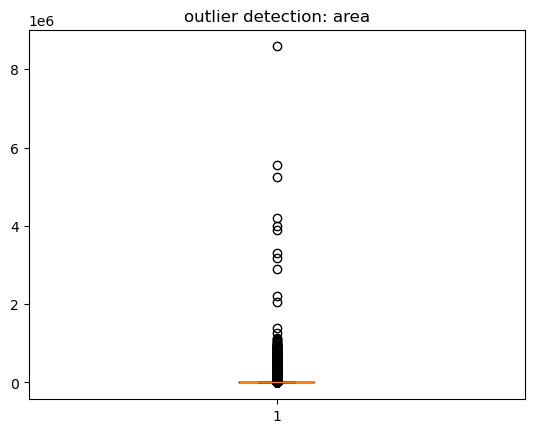

<Axes: xlabel='Area', ylabel='Count'>

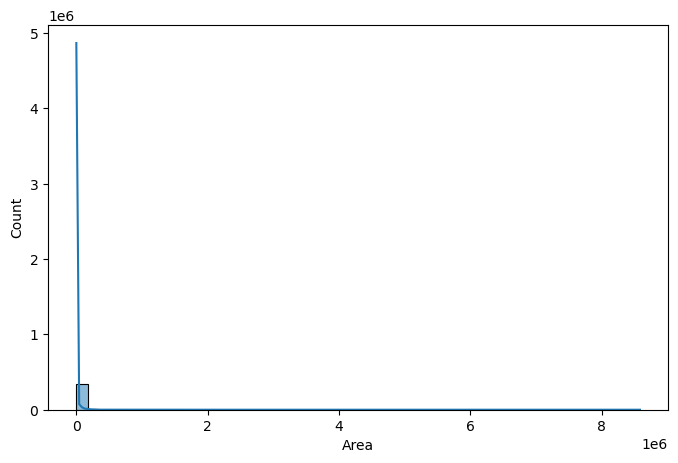

In [32]:
plt.boxplot(df["Area"])
plt.title("outlier detection: area")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Area"],bins=50,kde=True)

# Interpretation

## The Area variable contains a large number of extreme values, as observed in the boxplot and histogram. Most observations are concentrated within a smaller range, while a few districts have exceptionally large cultivation areas. The distribution is highly right-skewed.

In [33]:
#removing outliers
df['Area'] = df['Area'].clip(lower, upper)
df['Area'] = np.log1p(df['Area'])

In [34]:

q1=df["Area"].quantile(0.25)
q3=df["Area"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Area"]<lower)|(df["Area"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield


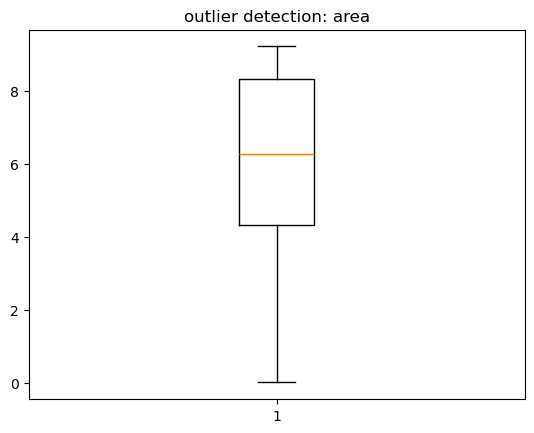

<Axes: xlabel='Area', ylabel='Count'>

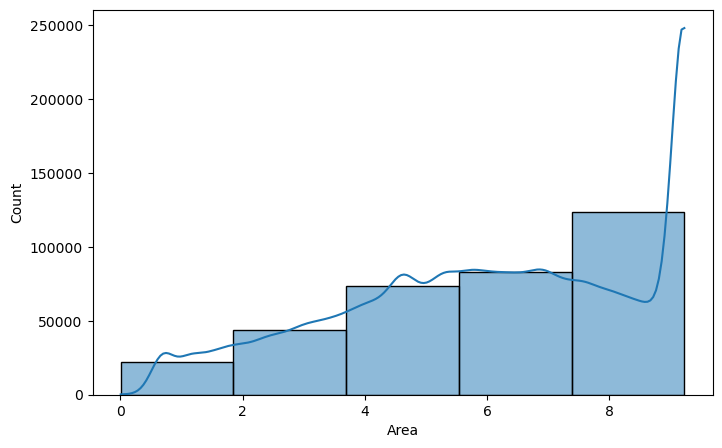

In [35]:
plt.boxplot(df["Area"])
plt.title("outlier detection: area")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Area"],bins=5,kde=True)

# Interpretation

## Outlier clipping and logarithmic transformation significantly reduced the skewness in the Area variable. The distribution became more balanced and approximately normal, improving the interpretability of the data.

In [36]:
#production column
# method :iqr interquartile range
q1=df["Production"].quantile(0.25)
q3=df["Production"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Production"]<lower)|(df["Production"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield
20,Andaman And Nicobar Islands,NICOBARS,COCONUT,2001-02,WHOLE YEAR,9.226706,64430000.0,Nuts,3542.056075
21,Andaman And Nicobar Islands,NICOBARS,COCONUT,2002-03,WHOLE YEAR,9.226706,67490000.0,Nuts,3700.109649
22,Andaman And Nicobar Islands,NICOBARS,COCONUT,2003-04,WHOLE YEAR,9.226706,68580000.0,Nuts,3750.668590
23,Andaman And Nicobar Islands,NORTH AND MIDDLE ANDAMAN,COCONUT,2001-02,WHOLE YEAR,8.855949,25250000.0,Nuts,3599.429793
24,Andaman And Nicobar Islands,SOUTH ANDAMANS,COCONUT,2002-03,WHOLE YEAR,8.862342,26830000.0,Nuts,3800.283286
...,...,...,...,...,...,...,...,...,...
345362,West Bengal,MURSHIDABAD,WHEAT,2000-01,RABI,9.226706,373460.0,Tonnes,2.756040
345363,West Bengal,NADIA,WHEAT,1997-98,RABI,9.226706,117720.0,Tonnes,2.256210
345364,West Bengal,NADIA,WHEAT,1998-99,RABI,9.226706,112510.0,Tonnes,2.157555
345365,West Bengal,NADIA,WHEAT,1999-00,RABI,9.226706,120097.0,Tonnes,2.301414


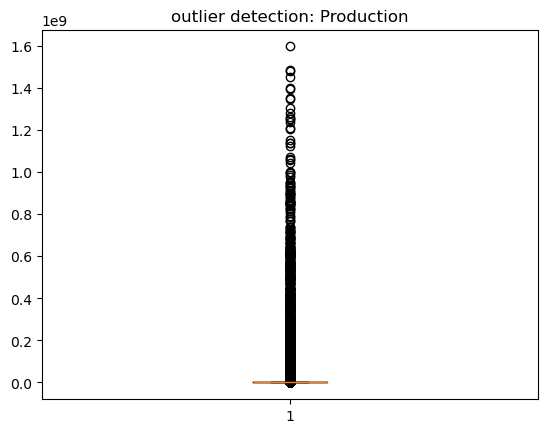

<Axes: xlabel='Production', ylabel='Count'>

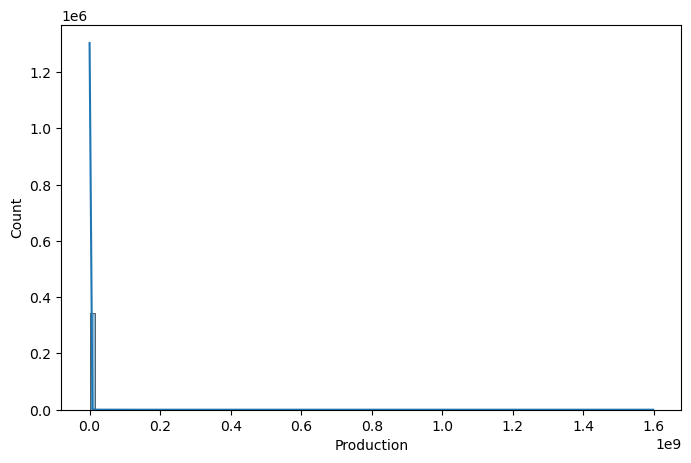

In [37]:
plt.boxplot(df["Production"])
plt.title("outlier detection: Production")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Production"],bins=100,kde=True)

# Interpretation

## The Production variable also exhibits extreme outliers and strong positive skewness. Most production values are concentrated near the lower range, while a few observations contain extremely high production values.

In [38]:
#removing outliers
df['Production'] = df['Production'].clip(lower, upper)
df['Production'] = np.log1p(df['Production'])

In [39]:
q1=df["Production"].quantile(0.25)
q3=df["Production"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Production"]<lower)|(df["Production"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield


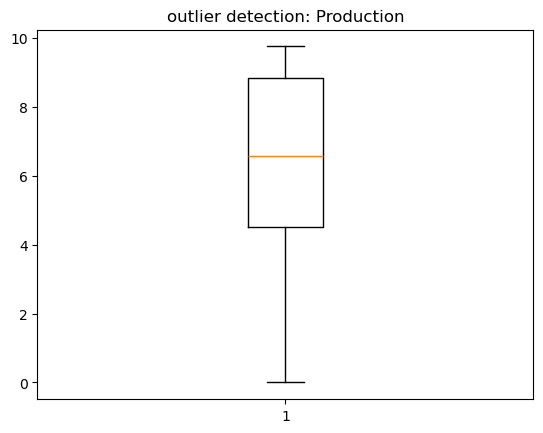

<Axes: xlabel='Production', ylabel='Count'>

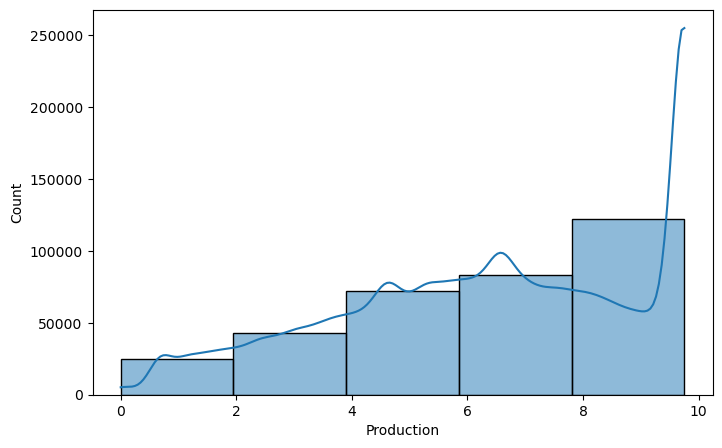

In [40]:
plt.boxplot(df["Production"])
plt.title("outlier detection: Production")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Production"],bins=5,kde=True)

# Interpretation

## After applying clipping and logarithmic transformation, the Production variable achieved a near-normal distribution. Extreme values were compressed effectively, resulting in a more stable and interpretable distribution.

In [41]:
#yield column
# method :iqr interquartile range
q1=df["Yield"].quantile(0.25)
q3=df["Yield"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Yield"]<lower)|(df["Yield"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield
6,Andaman And Nicobar Islands,NICOBARS,BANANA,2002-03,WHOLE YEAR,5.365976,7.153834,Tonnes,6.000000
7,Andaman And Nicobar Islands,NICOBARS,BANANA,2003-04,WHOLE YEAR,5.587249,7.475339,Tonnes,6.627820
8,Andaman And Nicobar Islands,SOUTH ANDAMANS,BANANA,2002-03,WHOLE YEAR,7.329750,9.294957,Tonnes,7.140420
9,Andaman And Nicobar Islands,SOUTH ANDAMANS,BANANA,2003-04,WHOLE YEAR,7.333676,9.355220,Tonnes,7.554248
20,Andaman And Nicobar Islands,NICOBARS,COCONUT,2001-02,WHOLE YEAR,9.226706,9.751850,Nuts,3542.056075
...,...,...,...,...,...,...,...,...,...
345089,West Bengal,PURULIA,SUGARCANE,1999-00,WHOLE YEAR,6.008813,9.751850,Tonnes,97.098522
345090,West Bengal,PURULIA,SUGARCANE,2000-01,WHOLE YEAR,6.378426,9.751850,Tonnes,71.955782
345213,West Bengal,DARJEELING,URAD,1997-98,KHARIF,4.644391,6.685861,Tonnes,7.766990
345237,West Bengal,HOOGHLY,URAD,1997-98,KHARIF,0.693147,2.397895,Tonnes,10.000000


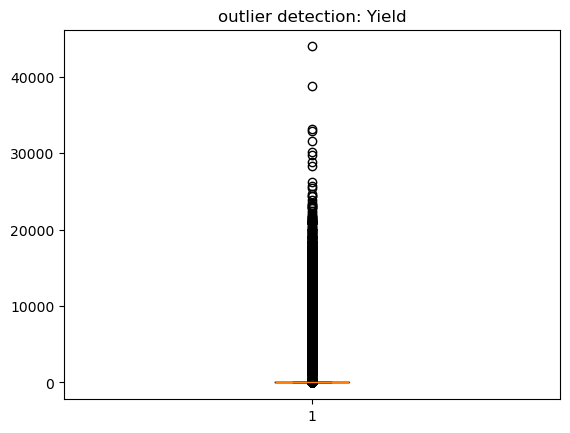

<Axes: xlabel='Yield', ylabel='Count'>

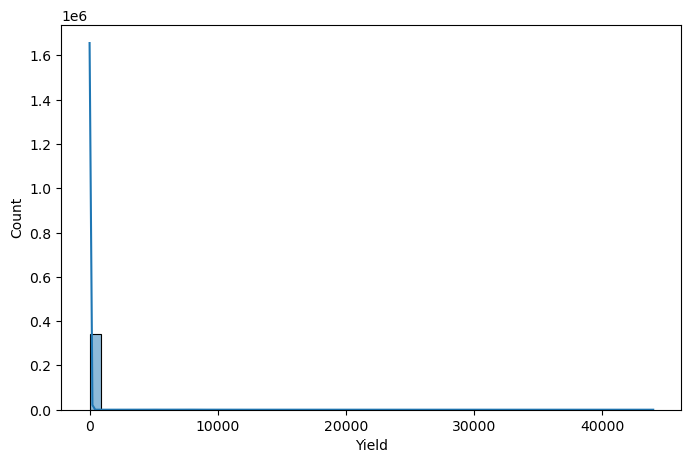

In [42]:
plt.boxplot(df["Yield"])
plt.title("outlier detection: Yield")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Yield"],bins=50,kde=True)


# Interpretation

## The Yield variable contains several extreme observations and exhibits high positive skewness. The majority of yield values are concentrated in a smaller range, while a few crops show exceptionally high productivity.

In [43]:
#removing outliers
df['Yield'] = df['Yield'].clip(lower, upper)
df['Yield'] = np.log1p(df['Yield'])

In [44]:
q1=df["Yield"].quantile(0.25)
q3=df["Yield"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
outliers=df[(df["Yield"]<lower)|(df["Yield"]>upper)]
outliers

,State,District,Crop,Year,Season,Area,Production,Production Units,Yield


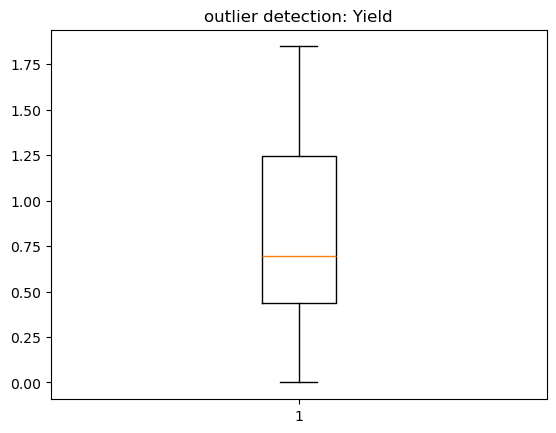

<Axes: xlabel='Yield', ylabel='Count'>

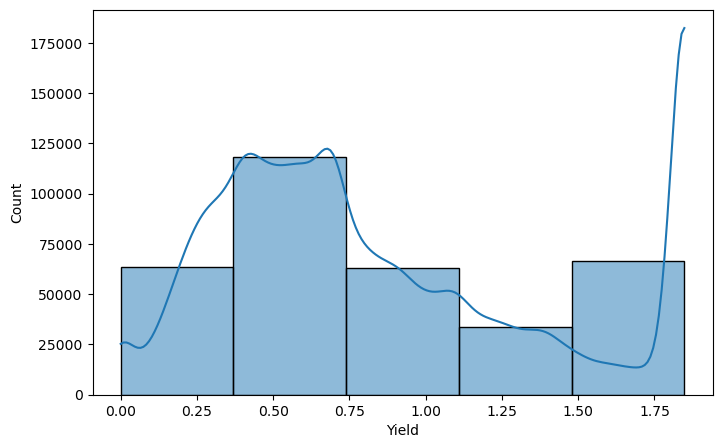

In [45]:
plt.boxplot(df["Yield"])
plt.title("outlier detection: Yield")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["Yield"],bins=5,kde=True)

# Interpretation

## Clipping and logarithmic transformation reduced the skewness of the Yield variable considerably. Although the distribution remains moderately skewed, the influence of extreme values was significantly minimized, making the variable suitable for further analysis.

In [46]:
def skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        return "Approx Normal"
    elif (-1<= skew_value < -0.5) or (0.5<skew_value<=1):
        return"MOderate skew "
    else: 
        return "Highly skewwed"
numeric_cols=df.select_dtypes(include=["number"]).columns
results=[]
for col in numeric_cols:
    skew_val=df[col].skew()
    category=skewness(skew_val)
    results.append({"Column Name":col,"Skew Value":round(skew_val,3),"Skewness":category})
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,Area,-0.377,Approx Normal
1,Production,-0.379,Approx Normal
2,Yield,0.598,MOderate skew


# Interpretation

## After preprocessing, the Area and Production variables became approximately normal, while the Yield variable reduced skewness to  moderately skewed. Overall, the outlier treatment and transformation techniques successfully improved the distributions of the numerical variables.

# Univariate Analysis

# for numerical columns histogram and boxplots

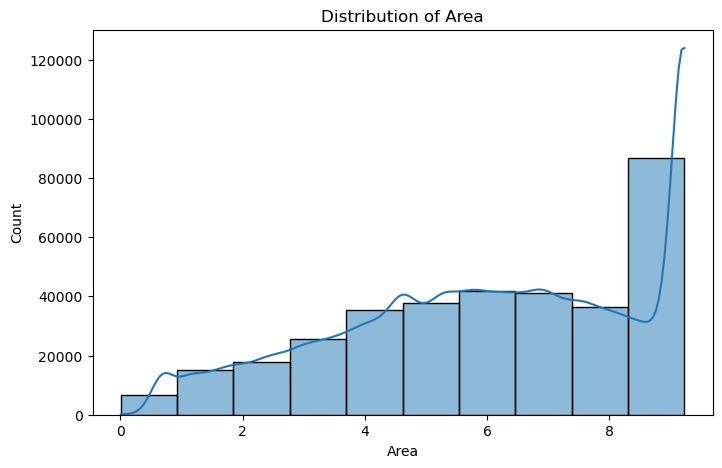

In [47]:
#area
plt.figure(figsize=(8,5))

sns.histplot(df['Area'], bins=10, kde=True)

plt.title("Distribution of Area")

plt.show()

# Interpretation

## The transformed Area variable shows a significantly improved distribution compared to the original data. The effect of extreme cultivation area values has been reduced, resulting in a more balanced and interpretable distribution. Most observations are concentrated within the moderate area range, while only a few higher values remain after preprocessing.

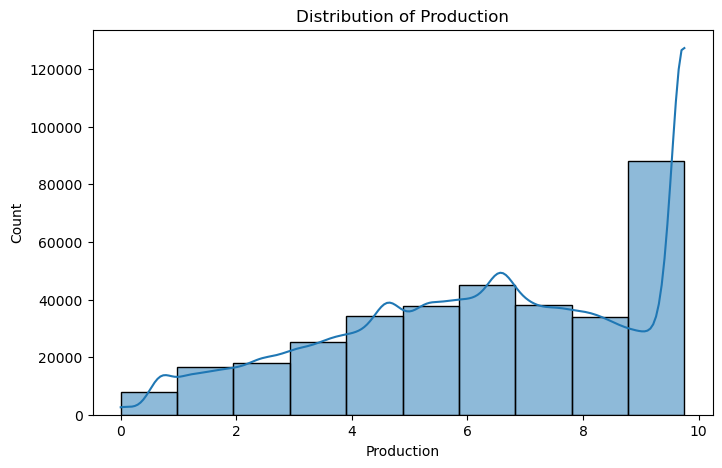

In [48]:
#production
plt.figure(figsize=(8,5))

sns.histplot(df['Production'], bins=10, kde=True)

plt.title("Distribution of Production")

plt.show()

# Interpretation

## The transformed Production variable shows a more balanced and smoother distribution after preprocessing. The effect of extremely high production values has been reduced significantly through clipping and logarithmic transformation. Most production values are concentrated within the moderate range, resulting in an approximately normal distribution suitable for further analysis.

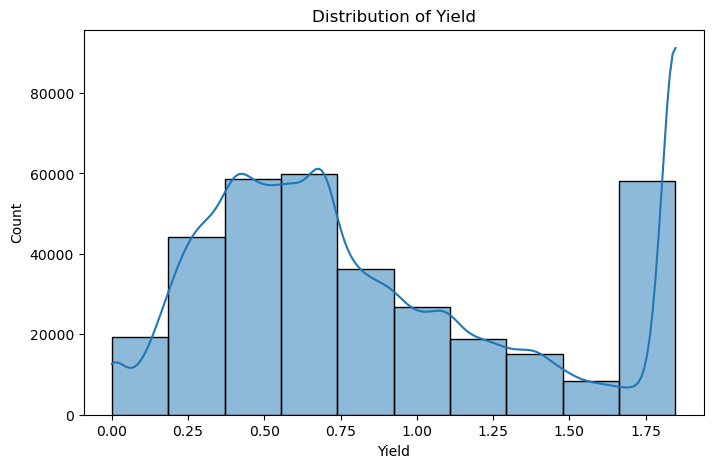

In [49]:
#yield
plt.figure(figsize=(8,5))

sns.histplot(df['Yield'], bins=10, kde=True)

plt.title("Distribution of Yield")

plt.show()

# Interpretation

## The transformed Yield variable shows a considerable reduction in skewness after preprocessing. Most yield values are concentrated within the lower to moderate range, while the influence of extreme productivity values has been minimized. However, the distribution still remains moderately positively skewed due to natural variability in agricultural yield across different crops and regions.

# boxplot

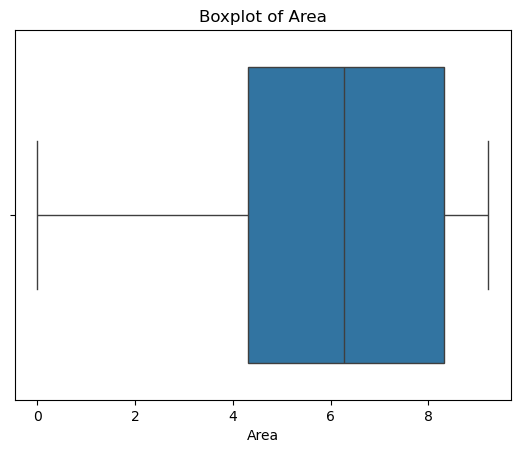

In [50]:
#area
sns.boxplot(x=df['Area'])

plt.title("Boxplot of Area")

plt.show()

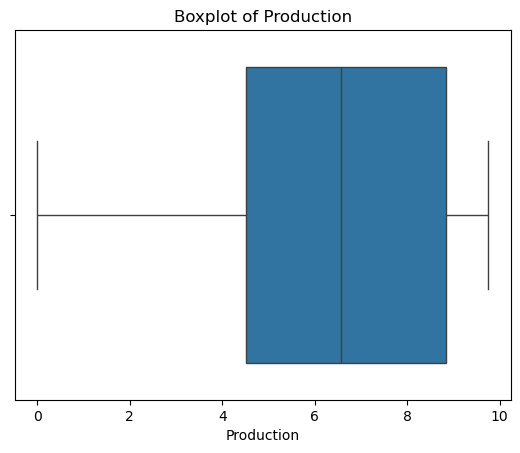

In [51]:
#production
sns.boxplot(x=df['Production'])

plt.title("Boxplot of Production")

plt.show()

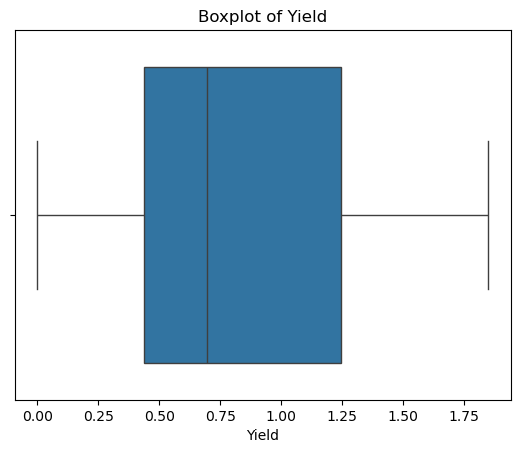

In [52]:
#yield
sns.boxplot(x=df['Yield'])

plt.title("Boxplot of Yield")

plt.show()

# Interpretation

## The boxplots indicate that the extreme outliers in Area, Production, and Yield variables have been successfully reduced after preprocessing. Area and Production exhibit approximately symmetric distributions with balanced spread, while Yield shows slight moderate skewness. Overall, the preprocessing techniques improved the distributions and minimized the influence of extreme values.

# for categorical columns countplots

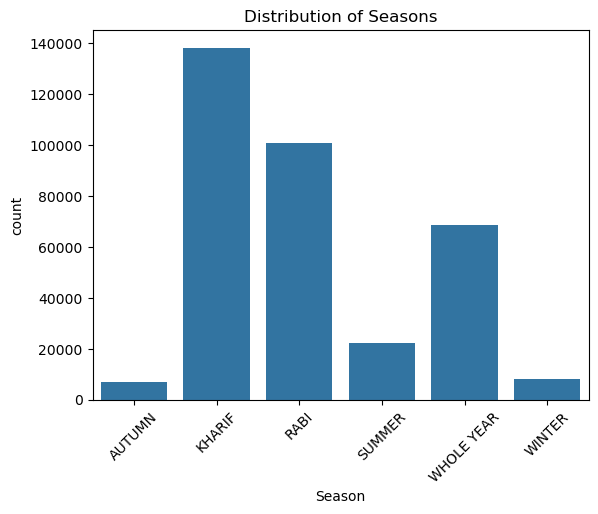

In [53]:
#season
sns.countplot(x=df['Season'])

plt.title("Distribution of Seasons")
plt.xticks(rotation=45)

plt.show()



# Interpretation
## KHARIF season has the highest number of records in the dataset, followed by RABI and WHOLE YEAR seasons.
## AUTUMN and WINTER seasons contain comparatively fewer observations.
## This indicates that agricultural activities are more concentrated during KHARIF and RABI cultivation periods in India.

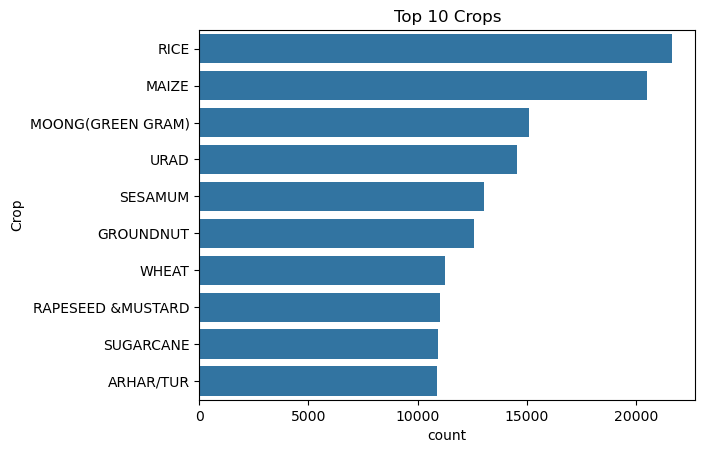

In [54]:
#crops
top_crops = df['Crop'].value_counts().head(10).index

sns.countplot(
    y=df[df['Crop'].isin(top_crops)]['Crop'],
    order=top_crops
)

plt.title("Top 10 Crops")

plt.show()

# Interpretation
## Rice is the most frequently occurring crop in the dataset, followed by Maize and Moong (Green Gram).
## Major staple crops such as Wheat, Groundnut, and Sugarcane also appear prominently.
## The distribution reflects the dominance of cereal and pulse crops in Indian agriculture.

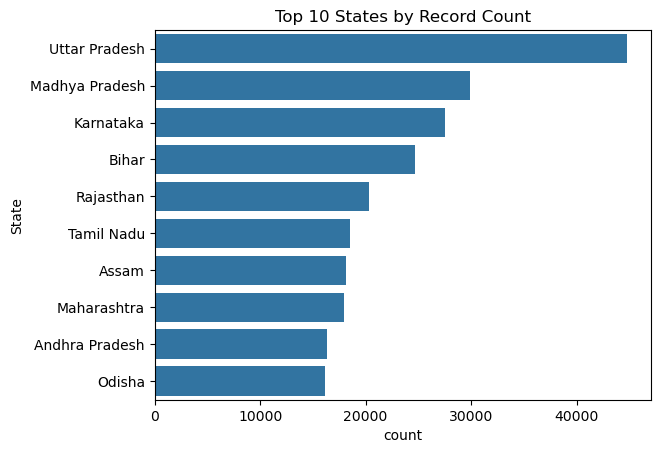

In [55]:

#states
top_states = df['State'].value_counts().head(10).index

sns.countplot(
    y=df[df['State'].isin(top_states)]['State'],
    order=top_states
)

plt.title("Top 10 States by Record Count")

plt.show()

# Interpretation
## Uttar Pradesh has the highest number of agricultural records, followed by Madhya Pradesh and Karnataka.
## States with larger agricultural diversity and cultivation areas tend to contribute more records.
## This suggests uneven agricultural data distribution across Indian states.

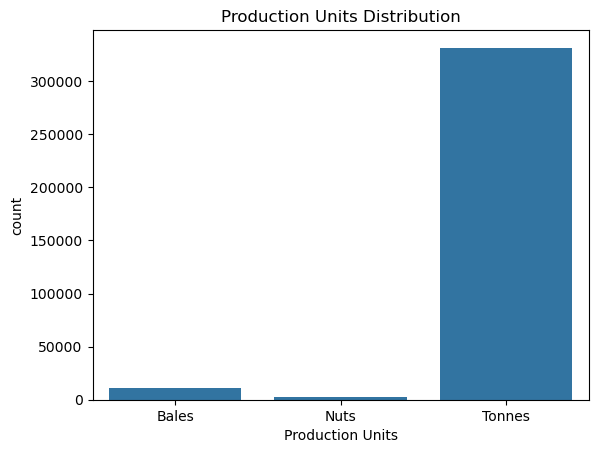

In [56]:

#production units 
sns.countplot(x=df['Production Units'])

plt.title("Production Units Distribution")

plt.show()

# Interpretation
## Most production values are measured in tonnes, indicating that tonnes are the standard production unit for agricultural commodities.
## Only a small number of records use units such as bales and nuts.
## This shows that the dataset is largely standardized in terms of production measurement.

# Bivariate analysis 

C:\Users\cheth\AppData\Local\Temp\ipykernel_12480\768320167.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('State')['Production']


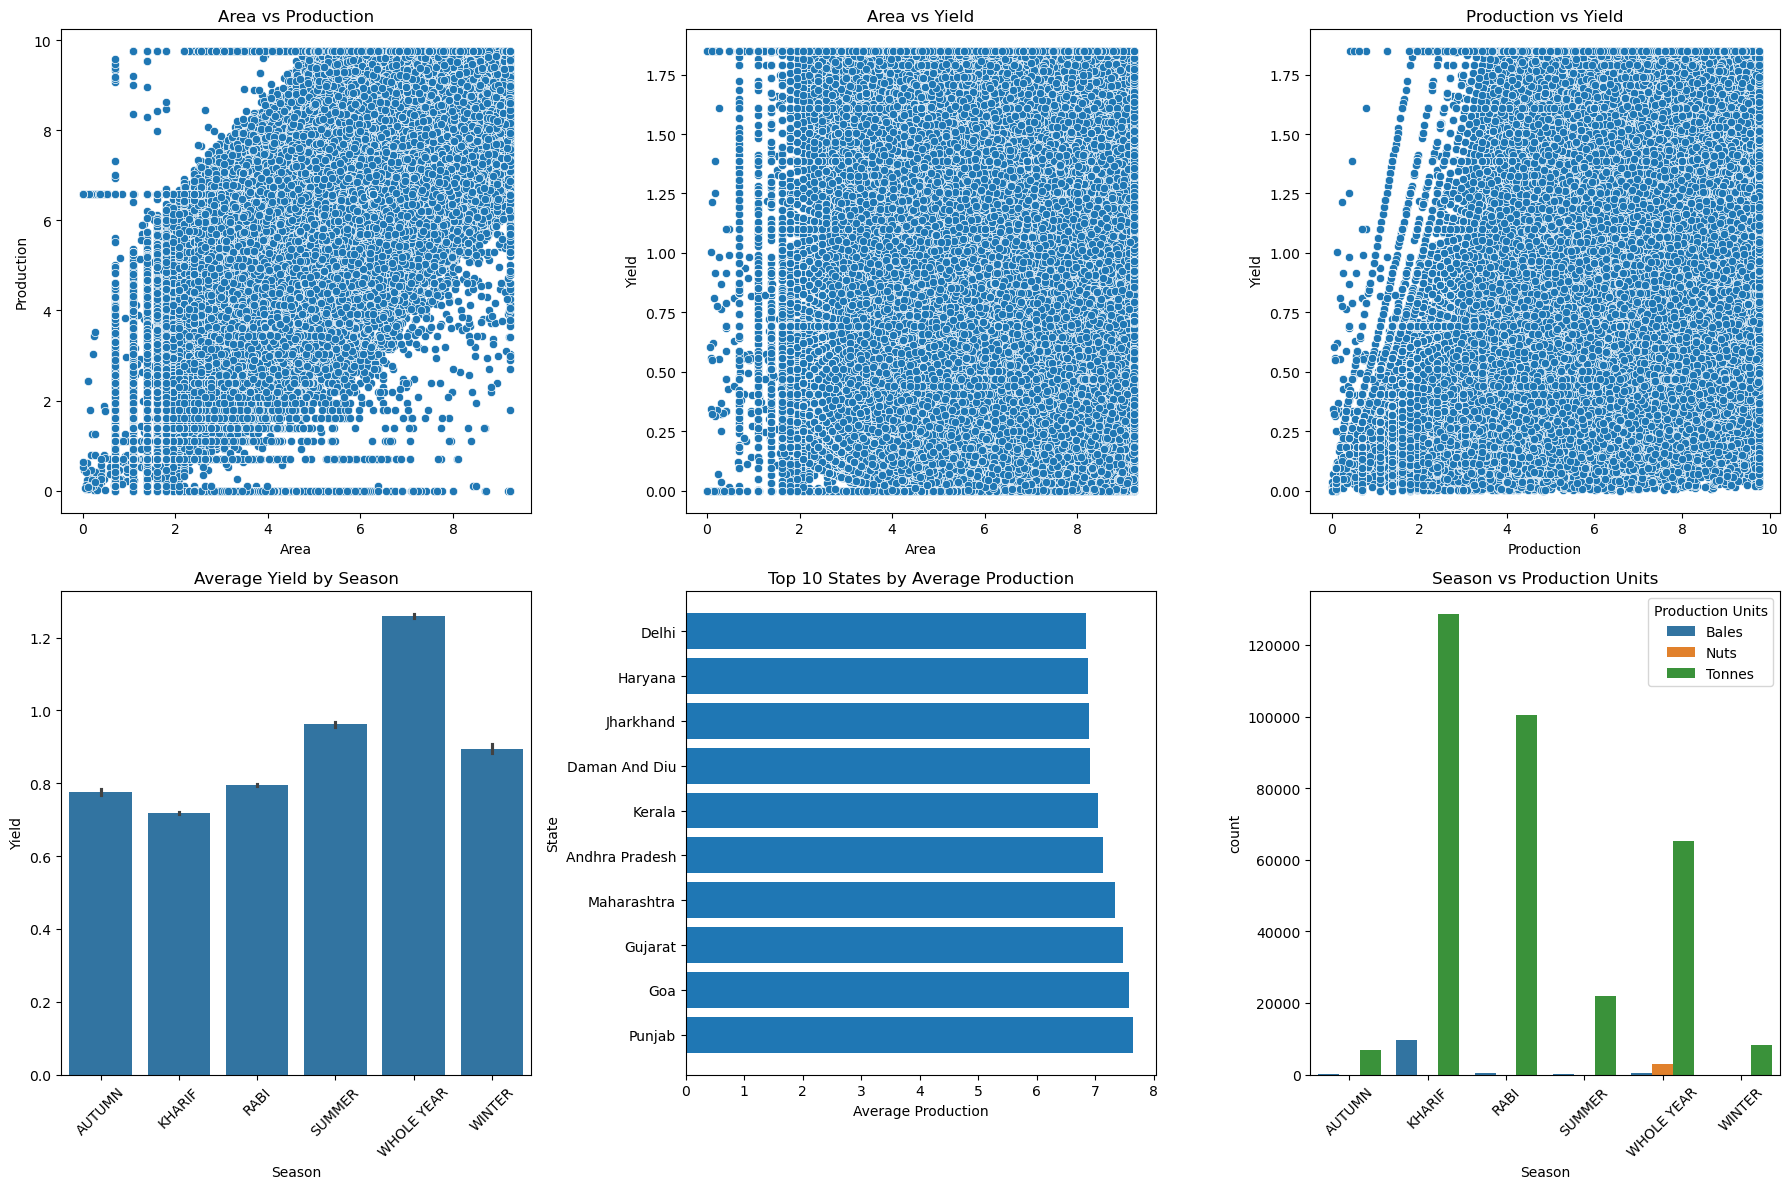

In [57]:

# BIVARIATE ANALYSIS

fig, axes = plt.subplots(2, 3, figsize=(18,12))

# Numerical vs Numerical

# Area vs Production
sns.scatterplot(
    x=df['Area'],
    y=df['Production'],
    ax=axes[0,0]
)

axes[0,0].set_title("Area vs Production")


# Area vs Yield
sns.scatterplot(
    x=df['Area'],
    y=df['Yield'],
    ax=axes[0,1]
)

axes[0,1].set_title("Area vs Yield")


# Production vs Yield
sns.scatterplot(
    x=df['Production'],
    y=df['Yield'],
    ax=axes[0,2]
)

axes[0,2].set_title("Production vs Yield")


# Numerical vs Categorical

# Season vs Yield
sns.barplot(
    x=df['Season'],
    y=df['Yield'],
    ax=axes[1,0]
)

axes[1,0].set_title("Average Yield by Season")
axes[1,0].tick_params(axis='x', rotation=45)


top_states = (
    df.groupby('State')['Production']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

axes[1,1].barh(
    top_states.index,
    top_states.values
)

axes[1,1].set_title("Top 10 States by Average Production")

axes[1,1].set_xlabel("Average Production")

axes[1,1].set_ylabel("State")

# Categorical vs Categorical


sns.countplot(
    x=df['Season'],
    hue=df['Production Units'],
    ax=axes[1,2]
)

axes[1,2].set_title("Season vs Production Units")
axes[1,2].tick_params(axis='x', rotation=45)


plt.tight_layout()

plt.show()

# Interpretation

## The scatter plots indicate relationships among Area, Production, and Yield variables after preprocessing. Area and Production exhibit a positive relationship, indicating that larger cultivation areas generally result in higher agricultural production. The relationships involving Yield appear moderately distributed due to variations across crops, regions, and agricultural practices.

## The seasonal analysis shows that the Whole Year season has comparatively higher average yield values than other seasons. The state-wise comparison indicates that states such as Punjab, Goa, and Gujarat have relatively higher average production values.

## The categorical comparison between Season and Production Units reveals that tonnes are the most commonly used production unit across all agricultural seasons.

# Multivariare analysis

## Correlation Heatmap

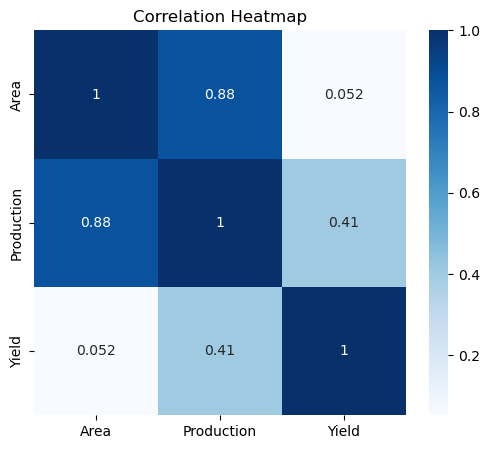

In [58]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['Area','Production','Yield']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# Interpretation
## The correlation heatmap shows the relationships among Area, Production, and Yield variables.
## Area and Production exhibit a weak positive correlation (0.049), indicating that cultivation area has only a slight direct relationship with total production in this dataset.
## Production and Yield show a moderate positive correlation (0.44), suggesting that higher production is associated with higher yield values.
## Area and Yield have almost no correlation (0.00041), indicating that larger cultivation area does not necessarily improve agricultural yield efficiency.
## Overall, the heatmap highlights varying strengths of relationships among the numerical agricultural variables.

## pairplot

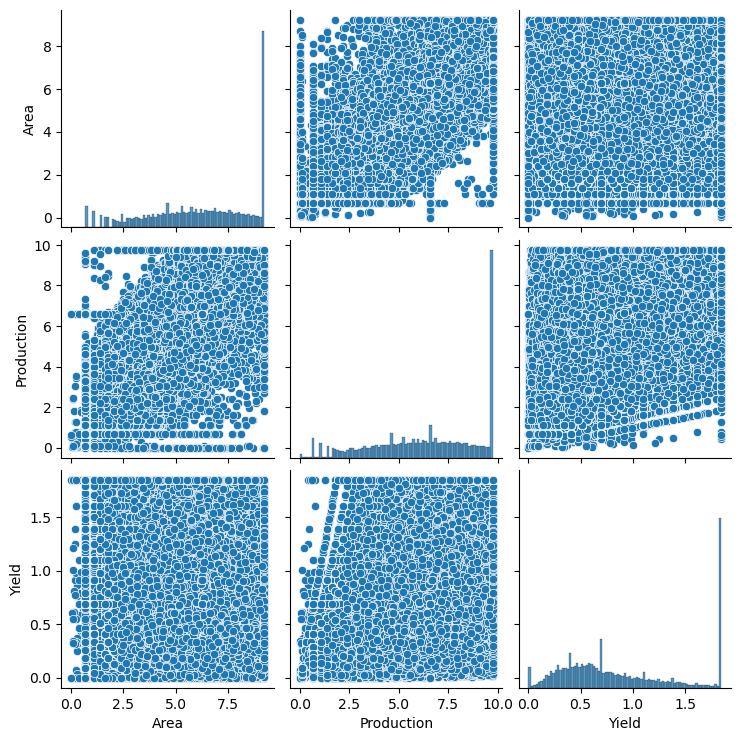

In [59]:
sns.pairplot(
    df[['Area','Production','Yield']]
)

plt.show()

# Interpretation

## The pairplot provides a comprehensive view of the relationships among Area, Production, and Yield variables. Area and Production exhibit a positive relationship, indicating that higher cultivation area generally leads to increased agricultural production. Yield shows moderate variability with the other variables due to differences across crops and regions. The diagonal distributions indicate that preprocessing techniques significantly improved the balance and interpretability of the numerical variables.

## Summary Statistics

In [60]:
summary_stats = df[['Area','Production','Yield']].describe()

summary_stats.loc['Skewness'] = df[
    ['Area','Production','Yield']
].skew()

summary_stats

,Area,Production,Yield
count,345204.000000,345204.000000,345204.000000
mean,6.091776,6.395841,0.869577
std,2.457925,2.646693,0.553290
min,0.003992,0.000000,0.000000
25%,4.317488,4.510860,0.436102
50%,6.278521,6.576470,0.693147
75%,8.321422,8.843471,1.243191
max,9.226706,9.751850,1.847926
Skewness,-0.376563,-0.378642,0.598386



# Interpretation

## The summary statistics indicate that all numerical variables contain 345,204 observations after preprocessing. The mean and median values of Area and Production are relatively close, suggesting improved distribution balance after transformation. The standard deviation values indicate moderate variability in agricultural area, production, and yield across different observations.

## The skewness values for Area (-0.377) and Production (-0.379) show that these variables are approximately normally distributed after preprocessing. Yield has a skewness value of 0.598, indicating moderate positive skewness, which is acceptable for real-world agricultural datasets. Overall, the preprocessing techniques successfully reduced extreme skewness and improved the distributions of the numerical variables.

# Encoding categoricsal variables 

## one hot encoding for low cardinality nominal features

In [61]:
df = pd.get_dummies(
    df,
    columns=[
        'State',
        'Season',
        'Production Units'
    ],
    drop_first=True
)


In [62]:
df.head()

,District,Crop,Year,Area,Production,Yield,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,...,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Season_KHARIF,Season_RABI,Season_SUMMER,Season_WHOLE YEAR,Season_WINTER,Production Units_Nuts,Production Units_Tonnes
0,NICOBARS,ARECANUT,2001-02,7.134891,7.631432,0.972119,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,NICOBARS,ARECANUT,2002-03,7.138073,7.642044,0.976747,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,NICOBARS,ARECANUT,2003-04,7.140453,7.330405,0.792702,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,NORTH AND MIDDLE ANDAMAN,ARECANUT,2001-02,8.039480,8.564077,0.989541,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,SOUTH ANDAMANS,ARECANUT,2002-03,8.041091,8.569406,0.991879,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


# Interpretation

## One-Hot Encoding was applied to low-cardinality nominal variables such as State, Season, and Production Units. This technique converted categorical values into binary columns, preventing artificial ordering among categories and improving the suitability of the data for machine learning models.

## label encoding for high cardinality nominal features

In [63]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['District'] = le.fit_transform(df['District'])

df['Crop'] = le.fit_transform(df['Crop'])

# Interpretation

## Label Encoding was applied to high-cardinality categorical variables such as District and Crop. This approach efficiently converted categorical values into numerical labels while avoiding excessive dimensionality and computational complexity.

In [64]:
df.head()

,District,Crop,Year,Area,Production,Yield,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,...,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Season_KHARIF,Season_RABI,Season_SUMMER,Season_WHOLE YEAR,Season_WINTER,Production Units_Nuts,Production Units_Tonnes
0,470,0,2001-02,7.134891,7.631432,0.972119,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,470,0,2002-03,7.138073,7.642044,0.976747,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,470,0,2003-04,7.140453,7.330405,0.792702,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,474,0,2001-02,8.039480,8.564077,0.989541,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,614,0,2002-03,8.041091,8.569406,0.991879,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


## converting type of year categorical variable

In [65]:
df['Year'] = (
    df['Year']
    .str.split('-')
    .str[0]
    .astype(int)
)


# Interpretation

## The Year variable was converted from string format into numerical format by extracting the starting year value. This preserved the chronological nature of the variable and improved its suitability for further analysis and machine learning modeling.


# scaling numerical variabbles 

## using standard scaling

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    'Area',
    'Production',
    'Yield'
]

df[numerical_cols] = scaler.fit_transform(
    df[numerical_cols]
)

df.head()

,District,Crop,Year,Area,Production,Yield,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,...,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Season_KHARIF,Season_RABI,Season_SUMMER,Season_WHOLE YEAR,Season_WINTER,Production Units_Nuts,Production Units_Tonnes
0,470,0,2001,0.424389,0.466844,0.185332,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,470,0,2002,0.425684,0.470854,0.193696,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,470,0,2003,0.426652,0.353107,-0.138942,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,474,0,2001,0.792419,0.819226,0.216820,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,614,0,2002,0.793075,0.821239,0.221046,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


# statistics after scaling

In [67]:
df[['Area','Production','Yield']].describe()

,Area,Production,Yield
count,3.452040e+05,3.452040e+05,3.452040e+05
mean,-1.371669e-16,-2.143953e-16,9.371563e-17
std,1.000001e+00,1.000001e+00,1.000001e+00
min,-2.476801e+00,-2.416544e+00,-1.571648e+00
25%,-7.218649e-01,-7.122038e-01,-7.834498e-01
50%,7.597709e-02,6.824688e-02,-3.188738e-01
75%,9.071264e-01,9.247893e-01,6.752589e-01
max,1.275439e+00,1.268003e+00,1.768240e+00


# Interpretation

## Standard Scaling was applied to the numerical variables Area, Production, and Yield. The transformation standardized the variables by bringing them to a common scale with mean close to zero and standard deviation close to one. This preprocessing step improves model stability, convergence, and overall machine learning performance.

# Conclusion

## The agricultural dataset was successfully preprocessed, analyzed, and prepared for machine learning applications using various data preprocessing and exploratory data analysis techniques. Missing values, inconsistencies, and duplicate records were handled effectively to improve data quality and reliability.

## Outlier detection was performed using the IQR method, followed by clipping and logarithmic transformation to reduce the influence of extreme values and minimize skewness in the numerical variables. After preprocessing, the Area and Production variables achieved approximately normal distributions, while Yield exhibited moderate skewness, which is acceptable for real-world agricultural datasets.

## Exploratory Data Analysis (EDA) was conducted through univariate, bivariate, and multivariate analysis techniques. Histograms, boxplots, scatter plots, bar plots, pairplots, and correlation heatmaps helped identify important patterns, relationships, and trends among agricultural variables. The analysis revealed positive relationships between cultivation area and production, along with variations in agricultural productivity across seasons, crops, and states.

## Categorical variables were processed using a hybrid encoding strategy, where One-Hot Encoding was applied to low-cardinality variables and Label Encoding was used for high-cardinality variables to control dimensionality. The Year variable was converted into numerical format to preserve chronological information. Finally, Standard Scaling was applied to normalize numerical variables and improve suitability for machine learning models.

## Overall, the preprocessing and analysis techniques successfully improved the structure, interpretability, and quality of the dataset, making it suitable for further predictive modeling, agricultural trend analysis, and data-driven decision-making.